# Null hypothesis tests

## General resampling approaches

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('https://www.fdsp.net/data/nls.csv')
df

,R0000100,T5597600,T5684500,T9900000
0,1,-5,-5,12
1,2,2,-3,12
2,3,2,115000,12
3,4,2,112850,14
4,5,-5,-5,18
...,...,...,...,...
12681,12682,-5,-5,12
12682,12683,-5,-5,12
12683,12684,-5,-5,12
12684,12685,-5,-5,14


In [5]:
df.rename(columns={
    'R0000100': 'CASE_ID',
    'T5597600': 'GENDER',
    'T5684500': 'NET_WEALTH',
    'T9900000': 'HIGHEST_GRADE_EVER'
}, inplace=True)
df.head()

,CASE_ID,GENDER,NET_WEALTH,HIGHEST_GRADE_EVER
0,1,-5,-5,12
1,2,2,-3,12
2,3,2,115000,12
3,4,2,112850,14
4,5,-5,-5,18


Usamos valores coherentes de acuerdo al codebook:

In [7]:
df2 = df.query('HIGHEST_GRADE_EVER >= 0 & (NET_WEALTH>=0 | NET_WEALTH < - 5)')
df2

,CASE_ID,GENDER,NET_WEALTH,HIGHEST_GRADE_EVER
2,3,2,115000,12
3,4,2,112850,14
5,6,1,95825,16
7,8,2,172717,14
8,9,1,679000,14
...,...,...,...,...
12642,12643,1,26900,12
12658,12659,1,-24500,16
12662,12663,1,62000,13
12666,12667,2,-8884,14


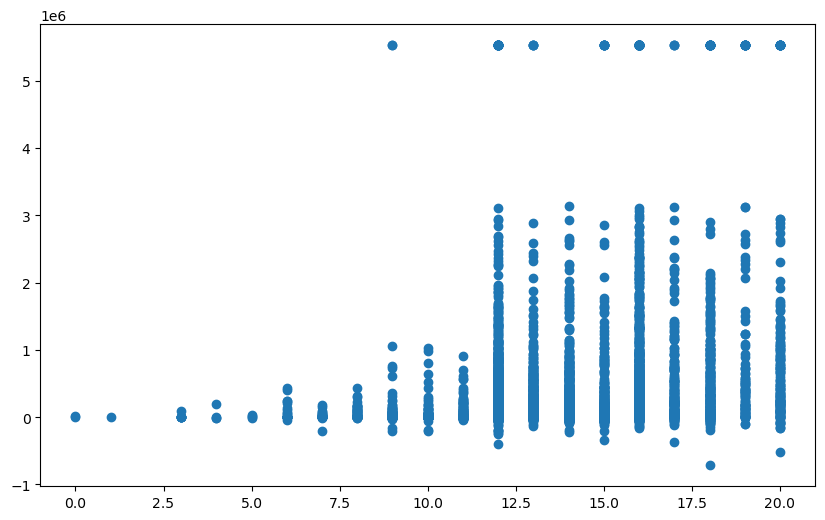

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(df2['HIGHEST_GRADE_EVER'], df2['NET_WEALTH'])
plt.show()

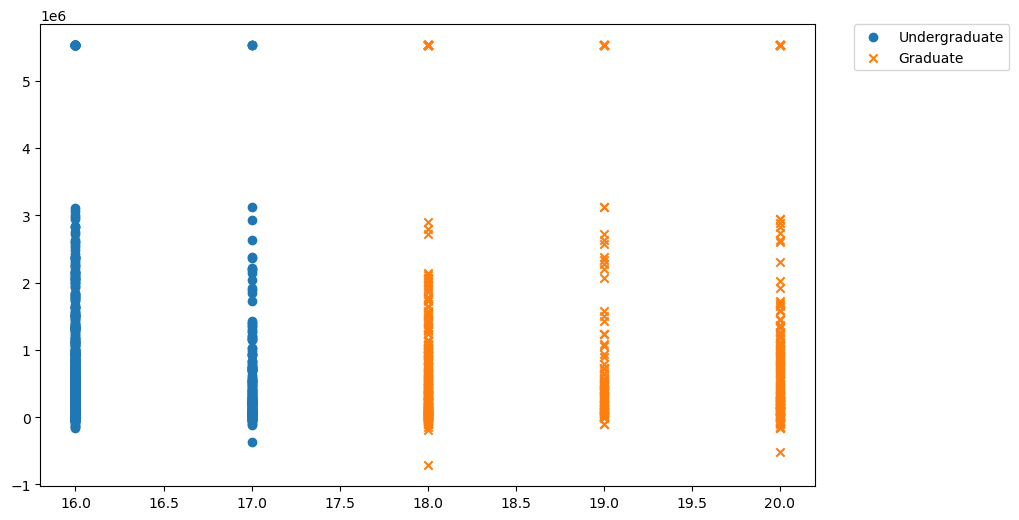

In [9]:
undergrad = df2.query('HIGHEST_GRADE_EVER >= 16 & HIGHEST_GRADE_EVER <= 17')
grad = df2.query('HIGHEST_GRADE_EVER >= 18')

plt.figure(figsize=(10,6))
plt.scatter(undergrad['HIGHEST_GRADE_EVER'], undergrad['NET_WEALTH'], label='Undergraduate')
plt.scatter(grad['HIGHEST_GRADE_EVER'], grad['NET_WEALTH'], marker='x', label='Graduate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

In [10]:
undergrad['NET_WEALTH'].max(), grad['NET_WEALTH'].max()

(5526252, 5526252)

In [11]:
undergrad['NET_WEALTH'].median(), grad['NET_WEALTH'].median()

(356325.0, 416000.0)

## Calculating p-values

In [13]:
num_sims = 10_000
threshold = 0.4
# Simulaciones entre [-0.5, 0.5)
diffs = np.random.rand(num_sims) - 0.5
'''
1. Comparamos las diferencias simuladas con el threshold
2. Contamos cuantas superan el threshold. Si se evalua como False, sera 0 en Python;
    contamos los 0s en Python con la funcion np.count_nonzero()
'''
np.count_nonzero(diffs >= threshold) / num_sims

0.0942

## How to draw samples from pooled data

In [15]:
grades1=np.array([74.1,  74.5])
grades2=np.array([79.4,79.0,  78.4,79.3])

### Bootstraping

In [17]:
pooled = np.hstack([grades1, grades2])
num_sims  =  10

#  Don't  worry  about  how  to  do  all  this  fancy  f-string  formatting! 
print(f'{"iter":^6}  {"pre-promotion":^16}  {"post-promotion":^24}' +  f'{"repeated  values":^20}') 
print(f'{"----":^6}  {"-"*14:^16}  {"-"*22:^24}    {"-"*22:^20}')

for  sim  in  range(num_sims):
    sample1 = np.random.choice(pooled, len(grades1) ) 
    sample2 = np.random.choice(pooled, len(grades2) )
    #  Find  the  repeated  values
    vals,  counts  =  np.unique(np.hstack(  (sample1,  sample2)  ), return_counts=True)
    print(f'{sim:^6}  {str(sample1):^16}  {str(sample2):^24}  ' +  f'{  str(vals[np.where(counts  >1  )]):^20}')

 iter    pre-promotion         post-promotion       repeated  values  
 ----    --------------    ----------------------     ----------------------
  0       [79.3 74.1]      [78.4 74.1 74.5 78.4]        [74.1 78.4]     
  1       [78.4 79. ]      [79.4 79.3 79.3 79.3]           [79.3]       
  2       [74.5 78.4]      [79.3 79.3 78.4 79.4]        [78.4 79.3]     
  3       [79.  79.3]      [79.3 79.3 79.3 78.4]           [79.3]       
  4       [79.4 79.4]      [79.4 79.  79.3 79.3]        [79.3 79.4]     
  5       [79.  74.5]      [78.4 79.  79.  78.4]        [78.4 79. ]     
  6       [74.5 79. ]      [78.4 79.4 79.3 79.3]           [79.3]       
  7       [79.3 79.4]      [74.5 79.  79.4 78.4]           [79.4]       
  8       [79.  79.3]      [79.3 79.3 74.5 79.4]           [79.3]       
  9       [74.1 79. ]      [74.5 79.3 79.4 79.4]           [79.4]       


## Bootstrap distribution and confidence intervals